# COPY in Layout Algebra

This notebook walks through the **COPY** algorithm from Cecka,
*CuTe Layout Representation and Algebra*
([arXiv:2603.02298](https://arxiv.org/abs/2603.02298), §2.6.1),
implemented in PyCuTe.

1. **Applications** — the same `copy(src, dst)` with different layouts
   realizes memcpy, gather/scatter, broadcast, transpose, …
2. **Optimizations** — how `pycute.alg.copy` reshapes that loop with
   `greatest_common_domain`, `nullspace`, and `right_inverse`.

Inspired by the pedagogical
[tensor-layouts algorithms notebook](https://github.com/facebookresearch/tensor-layouts/blob/main/examples/algorithms.ipynb),
adapted to PyCuTe's `Tensor` / `Ptr` / `print_tensor` surface.


In [1]:
import array
import contextlib
import importlib.util
import inspect
import io
import itertools
import sys
import tempfile
from pathlib import Path

from IPython.display import SVG, display

try:
    import pycute
except ModuleNotFoundError:
    # Running from a checkout without `pip install -e .`: find the repo root
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        if (root / "pycute" / "__init__.py").exists():
            sys.path.insert(0, str(root))
            break
    else:
        raise

from pycute import *
from pycute.alg import copy
from pycute.util import draw_svg, print_tensor

HAS_SVG = importlib.util.find_spec("svgwrite") is not None
if not HAS_SVG:
    print("svgwrite not installed; layout figures skipped. pip install -e '.[viz]'")


## Helpers

Demo tensors are built inline as a `Ptr` view over a typed
`array.array('u', ...)` buffer of letters: homogeneous storage, pre-filled, and
printable by `print_tensor`. The buffer must hold `coshape(layout)` elements --
a `Ptr` does not bounds-check -- and it stays alive through `Ptr.owner`.


In [2]:
from pycute.util.draw_colors import index_grey_8x

_SVG_DIR = Path(tempfile.mkdtemp(prefix="pycute-copy-"))
_SVG_COUNT = itertools.count()

def svg_of(layout):
    """
    `draw_svg` writes an SVG file rather than returning one, so send it to a
    scratch directory and hand the result to IPython.
    """
    if not HAS_SVG:
        return None
    path = _SVG_DIR / f"layout{next(_SVG_COUNT)}.svg"
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            draw_svg(layout, filename=str(path), color=index_grey_8x)
    except ValueError as e:
        print(f"(no figure for {layout}: {e})")
        return None
    return SVG(str(path))


def show(src, dst):
    """Draw each layout with equivalent coordinates, then print tensor data, then linear memory."""
    common_shape = wrap(common_coarsening(src, dst))
    for name, t in (("src", src), ("dst", dst)):
        print(f"{name}: {t}")
        t = composition(t, Layout(common_shape))  # Reshape to rank-sensitive common_shape
        svg = svg_of(t.layout)
        if svg is not None:
            display(svg)
        print(f"{name}:  logical data")
        print_tensor(t, print_type=False)
        print(f"{name}:  physical data")
        print_tensor(Tensor(t.accessor, Layout(coshape(t.layout))), print_type=False)
        print()

## Reference algorithm

COPY is a **rank-1 algorithm**: it iterates a single flat index space.
`src[i]` / `dst[i]` go through each layout's coordinate map, so the same
loop remaps arbitrarily between layouts.


In [3]:
from pycute.alg.ref import copy as copy_ref  # reference
print(inspect.getsource(copy_ref))

def copy(src: Tensor, dst: Tensor) -> None:
  """
  Reference COPY: `dst[i] = src[i]` for every flat index `i`.
  """
  if size(src) != size(dst):
    raise ValueError(f"copy: size mismatch {size(src)} != {size(dst)}")

  for i in range(size(dst)):
    dst[i] = src[i]



**Table 2** (Whitepaper) — applications that are all just `copy()` with
different source and destination layouts:

| Application | Source Layout | Destination Layout |
|---|---|---|
| 1D Arrays | `8:1` | `8:1` |
| ND Arrays | `(8,2,3):(1,16,32)` | `(8,2,3):(1,16,32)` |
| Gather | `(2,3,2):(42,1,128)` | `12:1` |
| Scatter | `12:1` | `(2,3,2):(42,1,128)` |
| Broadcast | `7:0` | `7:1` |
| Constant | `7:0` | `7:0` |
| Transpose | `(8,3):(1,8)` | `(8,3):(3,1)` |
| Tensor Transpose | `(8,(3,5)):(1,(57,8))` | `(8,15):(1,8)` |

The demos below use smaller shapes with the same structure.


### 1D copy (memcpy)

Identical layouts ⇒ a plain contiguous transfer.


src: Ptr(0x00007ed0e4df9110, c_wchar) o 8:1


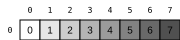

src:  logical data
A     B     C     D     E     F     G     H     
src:  physical data
A     B     C     D     E     F     G     H     

dst: Ptr(0x00007ed0e4935080, c_wchar) o 8:1


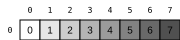

dst:  logical data
A     B     C     D     E     F     G     H     
dst:  physical data
A     B     C     D     E     F     G     H     



In [4]:
src = Tensor(Ptr(array.array('u', "ABCDEFGH")), Layout(8, 1))
dst = Tensor(Ptr(array.array('u', "........")), Layout(8, 1))

copy(src, dst)
show(src, dst)

### Transpose

Row-major `(M,N):(N,1)` → column-major `(M,N):(1,M)`. Same logical
coordinates; different physical order — the copy *is* the transpose.


src: Ptr(0x00007ed0ffcf31b0, c_wchar) o (4, 8):(8, 1)


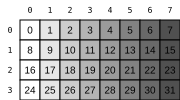

src:  logical data
A     B     C     D     E     F     G     H     
I     J     K     L     M     N     O     P     
Q     R     S     T     U     V     W     X     
Y     Z     0     1     2     3     4     5     
src:  physical data
A     B     C     D     E     F     G     H     I     J     K     L     M     N     O     P     Q     R     S     T     U     V     W     X     Y     Z     0     1     2     3     4     5     

dst: Ptr(0x00007ed0d7e263a0, c_wchar) o (4, 8):(1, 4)


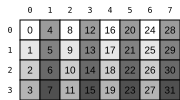

dst:  logical data
A     B     C     D     E     F     G     H     
I     J     K     L     M     N     O     P     
Q     R     S     T     U     V     W     X     
Y     Z     0     1     2     3     4     5     
dst:  physical data
A     I     Q     Y     B     J     R     Z     C     K     S     0     D     L     T     1     E     M     U     2     F     N     V     3     G     O     W     4     H     P     X     5     



In [5]:
M, N = 4, 8
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ012345"          # M*N == 32 elements

src = Tensor(Ptr(array.array('u', letters)), Layout((M, N), (N, 1)))
dst = Tensor(Ptr(array.array('u', "."*M*N)), Layout((M, N), (1, M)))

copy(src, dst)
show(src, dst)

### Gather and Scatter

Gather: strided source → contiguous destination.
Scatter: the reverse. Both are still `copy()`.


src: Ptr(0x00007ed0d7e74270, c_wchar) o (2, 3):(4, 1)


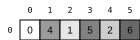

src:  logical data
A     E     B     F     C     G     
src:  physical data
A     B     C     D     E     F     G     

dst: Ptr(0x00007ed0d7e77250, c_wchar) o 6:1


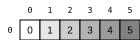

dst:  logical data
A     E     B     F     C     G     
dst:  physical data
A     E     B     F     C     G     



In [6]:
# Gather: (2,3):(4,1) -> 6:1
src = Tensor(Ptr(array.array('u', "ABCDEFG")), Layout((2, 3), (4, 1)))  # coshape == 7
dst = Tensor(Ptr(array.array('u', "......")), Layout(6, 1))

copy(src, dst)
show(src, dst)

src: Ptr(0x00007ed0d7e773b0, c_wchar) o 6:1


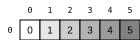

src:  logical data
A     B     C     D     E     F     
src:  physical data
A     B     C     D     E     F     

dst: Ptr(0x00007ed0d7e742d0, c_wchar) o (2, 3):(4, 1)


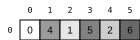

dst:  logical data
A     B     C     D     E     F     
dst:  physical data
A     C     E     .     B     D     F     



In [7]:
# Scatter: 6:1 -> (2,3):(4,1)
src = Tensor(Ptr(array.array('u', "ABCDEF")), Layout(6, 1))
dst = Tensor(Ptr(array.array('u', ".......")), Layout((2, 3), (4, 1)))  # coshape == 7

copy(src, dst)
show(src, dst)

### Broadcast

A stride-0 source reads the same element for every index. Copying into
`7:1` replicates that value. (`nullspace` matters for the optimized path.)


src: Ptr(0x00007ed0d7e704c0, c_wchar) o 7:0


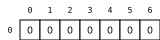

src:  logical data
A     A     A     A     A     A     A     
src:  physical data
A     

dst: Ptr(0x00007ed0d7f705d0, c_wchar) o 7:1


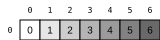

dst:  logical data
A     A     A     A     A     A     A     
dst:  physical data
A     A     A     A     A     A     A     



In [8]:
src = Tensor(Ptr(array.array('u', "A")), Layout(7, 0))  # coshape == 1
dst = Tensor(Ptr(array.array('u', ".......")), Layout(7, 1))

copy(src, dst)
show(src, dst)

### Constant

Stride-0 → stride-0: every logical index touches the same single cell.


src: Ptr(0x00007ed0d7e703f0, c_wchar) o 7:0


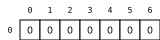

src:  logical data
Z     Z     Z     Z     Z     Z     Z     
src:  physical data
Z     

dst: Ptr(0x00007ed0d7e703d0, c_wchar) o 7:0


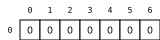

dst:  logical data
Z     Z     Z     Z     Z     Z     Z     
dst:  physical data
Z     



In [9]:
src = Tensor(Ptr(array.array('u', "Z")), Layout(7, 0))
dst = Tensor(Ptr(array.array('u', ".")), Layout(7, 0))

copy(src, dst)
show(src, dst)

### Tensor transpose

Reshape/flatten a hierarchical mode: `(4,6)` → `(4,(2,3))`.


src: Ptr(0x00007ed0d7d147a0, c_wchar) o (4, 6):(1, 4)


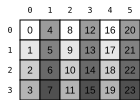

src:  logical data
A     E     I     M     Q     U     
B     F     J     N     R     V     
C     G     K     O     S     W     
D     H     L     P     T     X     
src:  physical data
A     B     C     D     E     F     G     H     I     J     K     L     M     N     O     P     Q     R     S     T     U     V     W     X     

dst: Ptr(0x00007ed0d7d14880, c_wchar) o (4, (2, 3)):(1, (14, 4))


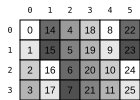

dst:  logical data
A     E     I     M     Q     U     
B     F     J     N     R     V     
C     G     K     O     S     W     
D     H     L     P     T     X     
dst:  physical data
A     B     C     D     I     J     K     L     Q     R     S     T     .     .     E     F     G     H     M     N     O     P     U     V     W     X     



In [10]:
src_layout = Layout((4, 6), (1, 4))               
dst_layout = Layout((4, (2, 3)), (1, (14, 4)))

src = Tensor(Ptr(array.array('u', "ABCDEFGHIJKLMNOPQRSTUVWX")), src_layout)  # coshape == 24
dst = Tensor(Ptr(array.array('u', "." * int(coshape(dst_layout)))), dst_layout)  # coshape == 26

copy(src, dst)
show(src, dst)

---

## COPY with Layout Analysis

The reference loop treats every element the same way: decompose `i`, evaluate
both layouts, load, store. There is a choice being made by the implementation
of `copy_ref`, however, and that choice is the iteration order of `i`. Indeed,
for any permutation `P`, the following is also a valid implementation

```python
for i in range(size(dst)):
  dst[P(i)] = src[P(i)]
```

(as long as no two indices write the same address — see Stage 2)

`pycute.alg.copy` uses the `src` and `dst` layouts to derive permutations that
*reshape the iteration space* so the loop runs over as few, as long, and as
regular pieces as possible.

Three algebraic stages do the reshaping, each establishing one invariant:

| Stage | Tool | Invariant it establishes |
|---|---|---|
| 1. Common domain | `greatest_common_domain` | the subdomain that is permutable by layouts |
| 2. Nullspace | `nullspace` | no *stride-0* coordinate writes an address twice |
| 3. Alignment | `right_inverse` | `dst` is walked **in memory order**, and the innermost run is **`V:1` in both** |

Whatever survives each stage is still consistent with COPY, so the optimized
version is never *less* correct — in the worst case it degrades all the way
back to one element at a time.


In [11]:
print(inspect.getsource(copy))

def copy(src: Tensor, dst: Tensor) -> None:
  """
  COPY with Layout Analysis
  """
  if size(src) != size(dst):
    raise ValueError(f"copy: size mismatch {size(src)} != {size(dst)}")

  # Extract the domain-compatible portions

  common_domain = greatest_common_domain(src, dst)
  src_c = logical_divide(src, common_domain)  # (Compat, InCompat)
  dst_c = logical_divide(dst, common_domain)  # (Compat, InCompat)

  # Account for nullspaces of dst and src within compatible portions

  null_dst = nullspace(dst_c.layout[0])
  src_n = logical_divide(src_c, (null_dst, None))  # ((Null, NonNull), InCompat)
  dst_n = logical_divide(dst_c, (null_dst, None))  # ((Null, NonNull), InCompat)

  if dst_n.layout[0][0](size(null_dst) - 1) != 0:
    raise ValueError(f"Sanity: nullspace definition error")
  if src_n.layout[0][0](size(null_dst) - 1) != 0:
    raise ValueError(f"Write-after-write error detected in dst: {dst}")

  # Slice the common stride-0 modes out
  src_n = src_n[(0,None),None]  # (Non

### Stage 1 — a shape both layouts can agree on

Every stage wants to logically permute `src` and `dst` *consistently*, which is
accomplished by applying the *same* tiler to each. But `composition` and
`logical_divide` are only admissible when the tiler "fits" the layout's shape.
Two tensors of equal size need not share any such tiler: the shapes `(5,7)` and
`(7,5)` both have 35 elements, but no non-trivial layout can permute both
consistently.

`greatest_common_domain(src, dst)` finds the largest subshape that both shapes
can be permuted by consistently, falling back to the singleton `(1,):(0,)` when
they share nothing. Splitting the two shapes by it divides each tensor into
`(Compat, InCompat)`: the compatible subshape the two agree on, and the
incompatible remainder. All of the further layout analysis then happens inside
`Compat`, while `InCompat` is simply iterated over.


In [12]:
for label, src, dst in [
    ("transpose", Layout((4, 8), (8, 1)),      Layout((4, 8), (1, 4))),
    ("gather",    Layout((2, 3), (4, 1)),      Layout(6, 1)),
    ("subdomain", Layout((4, 3, 5), (1, 7, 42)), Layout((6, 10), (1, 9))),
    ("coprime",   Layout((5, 7), (7, 1)),      Layout((7, 5), (5, 1))),
]:
    common = greatest_common_domain(src, dst)
    src_split, dst_split = logical_divide(src, common), logical_divide(dst, common)
    print(f"{label:10} src {str(src):22} dst {str(dst):20} common domain {common}")
    print(f"{'':10} src / common = {str(src_split):34} "
          f"Compat {size(src_split[0]):2}  InCompat {size(src_split[1])}")
    print(f"{'':10} dst / common = {str(dst_split):34} "
          f"Compat {size(dst_split[0]):2}  InCompat {size(dst_split[1])}")


transpose  src (4, 8):(8, 1)          dst (4, 8):(1, 4)        common domain (4, 8):(1, 4)
           src / common = ((4, 8), 1):((8, 1), 8)            Compat 32  InCompat 1
           dst / common = ((4, 8), 1):((1, 4), 32)           Compat 32  InCompat 1
gather     src (2, 3):(4, 1)          dst 6:1                  common domain (2, 3):(1, 2)
           src / common = ((2, 3), 1):((4, 1), 3)            Compat  6  InCompat 1
           dst / common = ((2, 3), 1):((1, 2), 6)            Compat  6  InCompat 1
subdomain  src (4, 3, 5):(1, 7, 42)   dst (6, 10):(1, 9)       common domain (2, 5):(1, 12)
           src / common = ((2, 5), (2, 3)):((1, 42), (2, 7)) Compat 10  InCompat 6
           dst / common = ((2, 5), (3, 2)):((1, 18), (2, 9)) Compat 10  InCompat 6
coprime    src (5, 7):(7, 1)          dst (7, 5):(5, 1)        common domain (1,):(0,)
           src / common = ((1,), (5, 7)):((0,), (7, 1))      Compat  1  InCompat 35
           dst / common = ((1,), (7, 5)):((0,), (5, 1))  

Read the `(Compat, InCompat)` pairs above as *how much of the copy is
optimizable*:

* **transpose** — the shapes are identical, so the common domain is the whole
  `(4,8)` and `InCompat` is a size-1 placeholder. Everything is optimizable.
* **gather** — `(2,3)` and `6` describe the same 6 elements at different
  granularities. The common domain refines the flat side to `(2,3):(1,2)`,
  again leaving nothing behind.
* **subdomain** — the interesting middle. `(4,3,5)` and `(6,10)` factor the
  same 60 elements differently, yet a 10-element domain still lines up:
  `(2,5):(1,12)` takes the `2` that `4` and `6` share up front, then the `5`
  that `(4,3,5)`'s tail shares with the even half of `10`. `Compat` holds
  those 10 elements and `InCompat` the remaining 6, so the copy becomes 6
  outer steps over a run the algebra *can* optimize, rather than
  all-or-nothing.
* **coprime** — the common domain collapses to `(1,):(0,)`, so `Compat` is
  empty and all 35 elements land in `InCompat`. The algorithm cannot beat the
  reference here, and it says so structurally rather than producing something
  wrong.

`InCompat` is never wrong, only unoptimized: it is iterated one step at a
time, and each step re-enters the machinery below.


### Stage 2 — nullspace: redundant writes and write-after-write

Layouts with stride-0 modes are very useful to represent broadcasted tensors,
but have some interesting properties. When copying broadcasted tensors, three
cases come up:

| | Src | Dst |
|---|---|---|
| Broadcast | `7:0` | `7:1` |
| Constant | `7:0` | `7:0` |
| WAW Error | `7:1` | `7:0` |

With `7:0` as our source tensor, one physical element is being used for all 7
elements of the logical tensor. In the Broadcast Case, this one physical
element is to be written to all 7 physical locations of the destination tensor.
In the Constant Case, this one physical element is to be written to one
physical location of the broadcasted destination tensor. Here, the reference
COPY would perform the same store 7 times, which we would prefer to avoid. In
the WAW Error Case, the source tensor has 7 physical elements that all want to
be stored to the same physical location in the destination tensor -- a
write-after-write error that we would like to catch.

To accomplish this, we can analyze the `nullspace` of the layouts.
`nullspace(L)` is the sublayout of coordinates that `L` sends to offset `0` —
for a tensor, these are exactly the coordinates that all target the *same*
address. Here's an example that demonstrates Stage 2:

In [13]:
# dst mode 1 has stride 0, so the 5 entries of each row collapse onto one address
dst_layout = Layout((3, 5), (1, 0))
null_dst = nullspace(dst_layout)
print(f"dst_layout {dst_layout}   {size(dst_layout)} coordinates over {coshape(dst_layout)} addresses")
print(f"nullspace  {null_dst} -> every {size(null_dst)} entries share an address\n")

# Accepted while the source does not vary along that null direction
for note, src_layout in [("constant everywhere",     Layout((3, 5), (0, 0))),
                         ("constant along each row", Layout((3, 5), (1, 0))),
                         ("row-major",               Layout((3, 5), (5, 1)))]:
    dst_n = logical_divide(dst_layout, null_dst)  # (Null, NonNull)
    src_n = logical_divide(src_layout, null_dst)  # (Null, NonNull)
    if dst_n(size(null_dst) - 1) != 0:
        print(f"Sanity: nullspace definition error")
    if src_n(size(null_dst) - 1) != 0:
        print(f"rejected  src {src_layout} {note:12} -> Write-after-write error detected")
        print(f"  Null modes:  {src_n[0]}   {dst_n[0]}  are WAW Error Case")
    else:
        print(f"accepted  src {src_layout} {note:12}")
        print(f"  Null modes:  {src_n[0]}   {dst_n[0]}  are Constant Case")
        print(f"  Instead, copy({src_n[1]}, {dst_n[1]})")

dst_layout (3, 5):(1, 0)   15 coordinates over 3 addresses
nullspace  5:3 -> every 5 entries share an address

accepted  src (3, 5):(0, 0) constant everywhere
  Null modes:  5:0   5:0  are Constant Case
  Instead, copy(3:0, 3:1)
accepted  src (3, 5):(1, 0) constant along each row
  Null modes:  5:0   5:0  are Constant Case
  Instead, copy(3:1, 3:1)
rejected  src (3, 5):(5, 1) row-major    -> Write-after-write error detected
  Null modes:  5:1   5:0  are WAW Error Case


Dividing both tensors by `nullspace(dst)` isolates those coordinates into
their own leading mode. Each side is then evaluated at the *last* coordinate of
that mode, which is enough to tell whether the mode is identically zero.

* the destination check is a sanity assert — by definition its nullspace maps
  to offset `0`, so anything else means `nullspace` is misbehaving.
* the source check is the interesting one. A non-zero value means the source
  *varies* across coordinates that share one destination address: several
  distinct values are racing for one slot and the result depends on iteration
  order, so the copy is rejected as a **write-after-write error** rather than
  silently keeping whichever element happened to land last.

If the source is constant across that nullspace, the copy is **accepted** and those writes are all storing
the same value. Thus, we can drop the Null Mode to remove these duplicate operations like in the Constant Case. In the example above, 15 operations in the reference implementation become 3 operations after layout analysis.

One caveat: `nullspace` finds only the coordinates a layout sends to offset
`0`, so the WAW Error Case is caught only when the aliasing comes from a
stride-0 mode. A destination can also alias through *overlapping* strides —
`(10,6):(1,7)` sends both `(7,0)` and `(0,1)` to offset 7, yet its nullspace is
the trivial `1:0`. To catch these cases, additional injectivity checks may be desired.

### Stage 3 — align to memory order and memcpy

The simplest instance of COPY is memcpy, which can be viewed as a copy of layout `N:1` to `N:1`. What is the permutation `P` that would transform a layout `L` to `N:1`? 

```python
L o P => N:1
```

`right_inverse(dst)` is the (maximal) layout that "undoes" `dst`, so permuting **both**
tensors by it walks the domain in destination-memory order. That is the
alignment: from here on the destination is (maximally) a stride-1 array and the source is
re-expressed alongside it, whatever order it happens to be in.

Aligning is not by itself enough to vectorize. A hardware move needs a run
that is contiguous on *both* sides, so the width comes from the leading mode of
the aligned source: if it has stride 1 its size is the vector width `V`, and
otherwise `V` is 1. Dividing the aligned pair once more by `V` makes the slice
handed to `_memcpy` exactly `V:1` in `src` *and* `dst`.

That is a deliberately narrow contract, and it is what makes the memcpy
simple: it never inspects layouts, only whether the accessors are suitably
aligned and whether the hardware has a `V`-wide move.

In [14]:
def vector_dispatch(sl, dl):
    """What `copy` hands to `_memcpy`: the aligned run, its width, and the slices."""
    src, dst = make_tensor(sl), make_tensor(dl)
    common = greatest_common_domain(src, dst)
    src_c, dst_c = logical_divide(src, common), logical_divide(dst, common)

    null_dst = nullspace(dst_c.layout[0])
    src_n = logical_divide(src_c, (null_dst, None))[(0, None), None]
    dst_n = logical_divide(dst_c, (null_dst, None))[(0, None), None]

    # Align both sides to destination-memory order
    inv_dst = right_inverse(dst_n.layout[0])
    src_v = logical_divide(src_n, (inv_dst, None))   # ((Id, NonId), Incompat)
    dst_v = logical_divide(dst_n, (inv_dst, None))

    # The width is the leading mode of the aligned source, if it is contiguous
    lead = coalesce(src_v.layout[0][0])[0]
    vec = size(lead) if stride(lead) == 1 else 1

    src_v = logical_divide(src_v, vec)               # (V, Rest)
    dst_v = logical_divide(dst_v, vec)
    copies = [(src_v[:, i].layout, dst_v[:, i].layout) for i in range(size[1](dst_v))]
    return lead, vec, copies

copy_cases = [
    ("memcpy",       Layout(32, 1),                     Layout(32, 1)),
    ("col-major",    Layout((4, 8), (1, 4)),            Layout((4, 8), (1, 4))),
    ("row-major",    Layout((4, 8), (8, 1)),            Layout((4, 8), (8, 1))),
    ("transpose",    Layout((4, 8), (8, 1)),            Layout((4, 8), (1, 4))),
    ("broadcast",    Layout(7, 0),                      Layout(7, 1)),
    ("constant",     Layout(7, 0),                      Layout(7, 0)),
    ("part bcast",   Layout((5, 4), (0, 1)),            Layout((5, 4), (4, 1))),
    ("hierarchical", Layout((4, (2, 3)), (1, (4, 12))), Layout((4, 6), (1, 4))),
    ("paper hier",   Layout(((2,2),(2,2)),((8,2),(4,1))), Layout(((2,2),(2,2)),((4,2),(8,1)))),
    ("subdomain",    Layout((4, 3, 5), (1, 7, 42)),     Layout((6, 10), (1, 9))),
    ("coprime",      Layout((5, 7), (7, 1)),            Layout((7, 5), (5, 1))),
]

for label, sl, dl in copy_cases:
    lead, vec, copies = vector_dispatch(sl, dl)
    s, d = copies[0]
    print(f"{label:12} aligned src leads {str(lead):8} -> V={vec:<2} {len(copies):3} copies of "
          f"src {str(coalesce(s)):7} dst {coalesce(d)}")


memcpy       aligned src leads 32:1     -> V=32   1 copies of src 32:1    dst 32:1
col-major    aligned src leads 32:1     -> V=32   1 copies of src 32:1    dst 32:1
row-major    aligned src leads 32:1     -> V=32   1 copies of src 32:1    dst 32:1
transpose    aligned src leads 4:8      -> V=1   32 copies of src 1:8     dst 1:1
broadcast    aligned src leads 7:0      -> V=1    7 copies of src 1:0     dst 1:1
constant     aligned src leads 1:0      -> V=1    1 copies of src 1:0     dst 1:0
part bcast   aligned src leads 4:1      -> V=4    5 copies of src 4:1     dst 4:1
hierarchical aligned src leads 8:1      -> V=8    3 copies of src 8:1     dst 8:1
paper hier   aligned src leads 4:1      -> V=4    4 copies of src 4:1     dst 4:1
subdomain    aligned src leads 2:1      -> V=2   30 copies of src 2:1     dst 2:1
coprime      aligned src leads 1:0      -> V=1   35 copies of src 1:7     dst 1:5


The middle column decides everything: the leading mode of the source once it is
expressed in destination order. Stride 1 there means a vector of that size;
anything else means one element at a time.

| Case | aligned src leads | V | dispatch |
|---|---|---|---|
| memcpy | `32:1` | 32 | one 32-wide move |
| col-major | `32:1` | 32 | one 32-wide move — the src/dst are in the same order |
| row-major | `32:1` | 32 | one 32-wide move — the src/dsr are in the same order |
| transpose | `4:8` | 1 | scalar: the leading stride is 8, not 1 |
| broadcast | `7:0` | 1 | scalar: a stride-0 read is not a vector load |
| constant | `1:0` | 1 | a single store, courtesy of stage 2 |
| part bcast | `4:1` | 4 | five 4-wide moves — each row is contiguous on both sides |
| hierarchical | `8:1` | 8 | three 8-wide moves — the `(4,(2,…))` modes coalesce |
| paper hier | `4:1` | 4 | four 4-wide moves — the Whitepaper's own vectorization example |
| subdomain | `2:1` | 2 | thirty 2-wide moves — the compatible tile is 10 wide, but only its leading pair is contiguous in both |
| coprime | `1:0` | 1 | scalar: nothing was compatible to begin with |

`col-major` and `row-major` copy a tensor onto its own layout, and both collapse
to a single 32-wide move because they are already in the same order. 
Pair those same two layouts *against each other* and the result
is `transpose`, where `V` falls to 1. What vectorizes is the relationship
between source and destination, not the shape of either alone.

The write order is often a separate win. `part bcast` shows both vector width
and write order at once: the reference hops `[0, 4, 8, 12, 16, 1, …]` down each
column, while the aligned loop writes `[0, 1, 2, 3, 4, 5, …]` straight through
— and *then* moves 4 elements at a time. `subdomain` shows how far the
alignment reaches when the pair only partly agrees: its 30 blocks start at
`[0, 18, 36, 54, 72]` and climb within each compatible tile, then the
incompatible mode steps and the climb restarts at `[2, 20, 38, …]`. Memory
order is recovered inside the compatible modes, not across them.

`paper hier` is the Whitepaper's own vectorization example and demonstrates that
the physical vector need not be logically contiguous at all.

### What it buys

Counting the calls made to the reference loop, against the one-write-per-element
the reference itself performs:


In [15]:
print(f"{'case':14} {'reference':>10} {'optimized':>24}")
for label, sl, dl in copy_cases:
    _, vec, copies = vector_dispatch(sl, dl)
    print(f"{label:14} {size(dl):6} writes   {len(copies):5} copies of len {vec}")

case            reference                optimized
memcpy             32 writes       1 copies of len 32
col-major          32 writes       1 copies of len 32
row-major          32 writes       1 copies of len 32
transpose          32 writes      32 copies of len 1
broadcast           7 writes       7 copies of len 1
constant            7 writes       1 copies of len 1
part bcast         20 writes       5 copies of len 4
hierarchical       24 writes       3 copies of len 8
paper hier         16 writes       4 copies of len 4
subdomain          60 writes      30 copies of len 2
coprime            35 writes      35 copies of len 1


Seven of the eleven find a real vector — `memcpy`, `col-major` and `row-major`
at the full 32, `hierarchical` at 8, `part bcast` and `paper hier` at 4, and
even `subdomain` at 2 — and the rest dispatch one element at a time. The other
wins are unchanged: `constant` collapses 7 writes to 1 through its nullspace,
and `coprime` reports honestly that there is nothing to exploit.

`V=1` is not a failure, it is the correct answer for a transpose or a stride-0
read: no permutation transforms those into a contiguous store.

We have walked from a trivial reference COPY to a COPY that permutes the
iteration order by deriving permutations from the source and destination
layouts. Correctness is the point of keeping the reference around: it is the
oracle the optimized path is checked and proven against, here and in
[`test/test_alg_copy.py`](../../test/test_alg_copy.py).


In [16]:
def letters(layout):
    t = Tensor(Ptr(array.array('u', "." * int(coshape(layout)))), layout)
    for i in range(size(layout)):
        t[i] = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789abcdefghijklmnopqrstuvwxyz"[i % 62]
    return t

for label, sl, dl in copy_cases:
    src = letters(sl)
    ref = Tensor(Ptr(array.array('u', "." * int(coshape(dl)))), dl)
    opt = Tensor(Ptr(array.array('u', "." * int(coshape(dl)))), dl)
    copy_ref(src, ref)
    copy(src, opt)
    agree = ref.accessor.owner.tounicode() == opt.accessor.owner.tounicode()
    print(f"{label:14} {'match' if agree else 'DIFFER'}   {opt.accessor.owner.tounicode()}")


memcpy         match   ABCDEFGHIJKLMNOPQRSTUVWXYZ012345
col-major      match   ABCDEFGHIJKLMNOPQRSTUVWXYZ012345
row-major      match   AEIMQUY2BFJNRVZ3CGKOSW04DHLPTX15
transpose      match   ABCDEFGHIJKLMNOPQRSTUVWXYZ012345
broadcast      match   GGGGGGG
constant       match   G
part bcast     match   EJOTEJOTEJOTEJOTEJOT
hierarchical   match   ABCDEFGHIJKLMNOPQRSTUVWX
paper hier     match   AICKBJDLEMGOFNHP
subdomain      match   ABCDEF...GHIJKL...MNOPQR...STUVWX...YZ0123...456789...abcdef...ghijkl...mnopqr...stuvwx
coprime        match   AHOV2BIPW3CJQX4DKRY5ELSZ6FMT07GNU18


## Next

* REDUCE and GEMM notebooks in `examples/algorithms/`, following the same
  reference-then-optimize shape.
* More "vector" patterns than simply a contiguous run: the vector-width is deliberately
  instruction-shaped, and other instructions look for other layouts entirely.
